# 📋 Análisis de Anotaciones — Archivos `.edf.st`

Los `.edf.st` son archivos PhysioBank que contienen:
- **Hipnograma**: etapas del sueño (S1–S4, REM, MT) por época de 30 s, anotadas según R&K
- **Eventos CAP fase A**: subtipo (A1, A2, A3), tiempo de inicio y duración

**Convención de columnas usada en todo el notebook:**

| DataFrame | Columnas clave |
|---|---|
| `stages_all` | `patient`, `onset_s`, `duration_s`, `stage_raw`, `stage`, `stage_code`, `stage_label`, `disorder` |
| `cap_all` | `patient`, `onset_s`, `duration_s`, `subtype`, `disorder` |

## 0 · Imports y configuración

In [40]:
import re
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── AJUSTA ESTA RUTA ─────────────────────────────────────────
BASE_PATH = Path.cwd() / '../data/cap-sleep-database'
# ────────────────────────────────────────────────────────────

OUT_DIR = BASE_PATH.parent / 'diagnostico_outputs'
OUT_DIR.mkdir(exist_ok=True)

st_files = sorted(BASE_PATH.glob('*.edf.st'))
print(f'Archivos .edf.st encontrados: {len(st_files)}')
for f in st_files[:5]:
    print(f'  {f.name}')
if len(st_files) > 5:
    print(f'  ... y {len(st_files) - 5} más')

Archivos .edf.st encontrados: 108
  brux1.edf.st
  brux2.edf.st
  ins1.edf.st
  ins2.edf.st
  ins3.edf.st
  ... y 103 más


## 1 · Constantes globales

Definidas una sola vez y reutilizadas en todas las celdas.

In [41]:
# ── Mapeo stage_raw → etiqueta normalizada (notación AASM) ───
STAGE_RAW_TO_LABEL = {
    'SLEEP-S1':  'N1',
    'SLEEP-S2':  'N2',
    'SLEEP-S3':  'N3',
    'SLEEP-S4':  'N3',   # S4 se agrupa con N3 (sueño profundo)
    'SLEEP-REM': 'REM',
    'SLEEP-MT':  'MT',
    'WAKE':      'W',
    'SLEEP-S0':  'W',
}

# ── Mapeo etiqueta → código numérico ────────────────────────
STAGE_LABEL_TO_CODE = {
    'W':   0,
    'N1':  1,
    'N2':  2,
    'N3':  3,
    'REM': 4,
    'MT':  5,
}

# ── Mapeo inverso código → etiqueta ─────────────────────────
STAGE_CODE_TO_LABEL = {v: k for k, v in STAGE_LABEL_TO_CODE.items()}

# ── Colores para gráficos ────────────────────────────────────
STAGE_COLORS = {
    0: '#E8E8E8',   # W   — gris claro
    1: '#AED6F1',   # N1  — azul pálido
    2: '#2980B9',   # N2  — azul
    3: '#1A5276',   # N3  — azul oscuro
    4: '#E74C3C',   # REM — rojo
    5: '#F39C12',   # MT  — naranja
}

CAP_COLORS = {
    'CAP-A1': '#27AE60',
    'CAP-A2': '#F39C12',
    'CAP-A3': '#C0392B',
}

# ── Mapeo prefijo → nombre de trastorno ─────────────────────
# Orden importa: prefijos más largos antes para evitar match parcial
DISORDER_PREFIXES = [
    ('brux',  'Bruxismo'),
    ('narco', 'Narcolepsia'),
    ('nfle',  'Epilepsia nocturna frontal'),
    ('plm',   'Movimientos periódicos'),
    ('rbd',   'Trastorno REM'),
    ('sdb',   'Trastorno respiratorio'),
    ('ins',   'Insomnio'),
]

def get_disorder(patient_name: str) -> str:
    name = patient_name.lower()
    for prefix, label in DISORDER_PREFIXES:
        if name.startswith(prefix):
            return label
    if re.match(r'^n\d', name):
        return 'Normal'
    return 'Desconocido'

print('Constantes definidas ✅')
print(f'  Etapas mapeadas : {list(STAGE_RAW_TO_LABEL.keys())}')
print(f'  Trastornos      : {[d for _, d in DISORDER_PREFIXES] + ["Normal"]}')

Constantes definidas ✅
  Etapas mapeadas : ['SLEEP-S1', 'SLEEP-S2', 'SLEEP-S3', 'SLEEP-S4', 'SLEEP-REM', 'SLEEP-MT', 'WAKE', 'SLEEP-S0']
  Trastornos      : ['Bruxismo', 'Narcolepsia', 'Epilepsia nocturna frontal', 'Movimientos periódicos', 'Trastorno REM', 'Trastorno respiratorio', 'Insomnio', 'Normal']


## 2 · Parser unificado

Un único parser que lee el binario `.edf.st` con regex y devuelve
`stages_df` y `cap_df` con las columnas definitivas ya normalizadas.

In [42]:
# Patrones compilados una sola vez
_STAGE_RE = re.compile(
    r'(SLEEP-S[0-4]|SLEEP-REM|SLEEP-MT|WAKE)\s+(\d+)',
    re.IGNORECASE,
)
_CAP_RE = re.compile(
    r'(CAP-A[123])\s+(\d+(?:\.\d+)?)',
    re.IGNORECASE,
)


def parse_edf_st(filepath: Path):
    """
    Lee un .edf.st y devuelve (stages_df, cap_df) con columnas definitivas:
      stages_df : patient, onset_s, duration_s, stage_raw,
                  stage, stage_code, stage_label
      cap_df    : patient, onset_s, duration_s, subtype
    """
    patient = filepath.stem.replace('.edf', '')
    text    = filepath.read_bytes().decode('latin-1', errors='replace')

    # ── Etapas: onset acumulado desde duraciones ─────────────
    stage_rows, onset = [], 0.0
    for m in _STAGE_RE.finditer(text):
        raw      = m.group(1).upper()
        duration = float(m.group(2))
        label    = STAGE_RAW_TO_LABEL.get(raw, 'UNKNOWN')
        code     = STAGE_LABEL_TO_CODE.get(label, -1)
        stage_rows.append({
            'patient':     patient,
            'onset_s':     onset,
            'duration_s':  duration,
            'stage_raw':   raw,
            'stage':       label,
            'stage_code':  code,
            'stage_label': STAGE_CODE_TO_LABEL.get(code, label),
        })
        onset += duration

    # ── Eventos CAP: onset acumulado desde duraciones ────────
    cap_rows, cap_onset = [], 0.0
    for m in _CAP_RE.finditer(text):
        duration = float(m.group(2))
        cap_rows.append({
            'patient':    patient,
            'onset_s':    cap_onset,
            'duration_s': duration,
            'subtype':    m.group(1).upper(),   # 'CAP-A1' / 'CAP-A2' / 'CAP-A3'
        })
        cap_onset += duration

    return pd.DataFrame(stage_rows), pd.DataFrame(cap_rows)


# ── Prueba con el primer archivo ─────────────────────────────
ejemplo   = st_files[0]
_s, _c    = parse_edf_st(ejemplo)

print(f'Archivo de prueba : {ejemplo.name}')
print(f'Épocas            : {len(_s)}')
print(f'Eventos CAP       : {len(_c)}')
print(f'Columnas stages   : {_s.columns.tolist()}')
print(f'Columnas cap      : {_c.columns.tolist()}')
print(f'\nEtapas únicas:')
print(_s['stage'].value_counts().to_string())
print(f'\nSubtypes únicos:')
print(_c['subtype'].value_counts().to_string())

Archivo de prueba : brux1.edf.st
Épocas            : 354
Eventos CAP       : 60
Columnas stages   : ['patient', 'onset_s', 'duration_s', 'stage_raw', 'stage', 'stage_code', 'stage_label']
Columnas cap      : ['patient', 'onset_s', 'duration_s', 'subtype']

Etapas únicas:
stage
N2     173
REM     88
W       38
N3      30
N1      25

Subtypes únicos:
subtype
CAP-A3    28
CAP-A1    26
CAP-A2     6


## 3 · Procesar todos los pacientes

In [43]:
all_stages, all_cap, errors = [], [], []
total = len(st_files)

for i, st_path in enumerate(st_files, 1):
    print(f'  [{i:>3}/{total}] {st_path.stem}', end='\r')
    try:
        s_df, c_df = parse_edf_st(st_path)
        all_stages.append(s_df)
        all_cap.append(c_df)
    except Exception as e:
        errors.append((st_path.name, str(e)))
        print(f'\n  ⚠️  Error en {st_path.name}: {e}')

stages_all = pd.concat(all_stages, ignore_index=True)
cap_all    = pd.concat(all_cap,    ignore_index=True)

# Añadir columna de trastorno
stages_all['disorder'] = stages_all['patient'].map(get_disorder)
cap_all['disorder']    = cap_all['patient'].map(get_disorder)

print(f'\nProcesados {total - len(errors)}/{total} archivos ✅')
if errors:
    print(f'⚠️  Errores en: {[e[0] for e in errors]}')
print(f'  Épocas totales  : {len(stages_all):,}')
print(f'  Eventos CAP-A   : {len(cap_all):,}')

# Verificar etapas sin mapear
unknown = stages_all[stages_all['stage'] == 'UNKNOWN']
if not unknown.empty:
    print(f'\n⚠️  {len(unknown)} épocas con etapa no reconocida:')
    print(unknown['stage_raw'].value_counts().to_string())
else:
    print('  Todas las etapas mapeadas correctamente ✅')

  [108/108] sdb4.edfff
Procesados 108/108 archivos ✅
  Épocas totales  : 106,355
  Eventos CAP-A   : 49,956
  Todas las etapas mapeadas correctamente ✅


## 4 · Distribución de etapas del sueño

,stage_label,horas_totales_dataset
0,W,161.150000
1,N1,38.041667
2,N2,319.900000
3,N3,209.875000
4,REM,157.275000
5,MT,0.050000


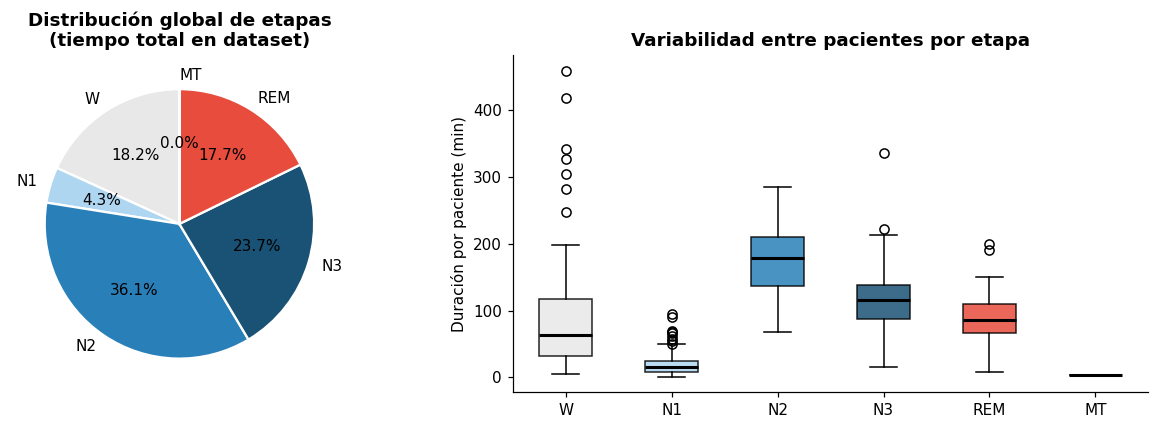

In [44]:
stage_time = (
    stages_all
    .groupby(['stage_code', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
    .assign(duration_h=lambda x: x['duration_s'] / 3600)
    .sort_values('stage_code')
)

stage_per_patient = (
    stages_all
    .groupby(['patient', 'stage_code', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
    .assign(duration_min=lambda x: x['duration_s'] / 60)
)

display(stage_time[['stage_label', 'duration_h']].rename(columns={'duration_h': 'horas_totales_dataset'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [STAGE_COLORS[c] for c in stage_time['stage_code']]
axes[0].pie(
    stage_time['duration_h'],
    labels=stage_time['stage_label'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
axes[0].set_title('Distribución global de etapas\n(tiempo total en dataset)', fontweight='bold')

order      = sorted(stage_per_patient['stage_code'].unique())
labels_ord = [STAGE_CODE_TO_LABEL[c] for c in order]
box_colors = [STAGE_COLORS[c] for c in order]

bp = axes[1].boxplot(
    [stage_per_patient[stage_per_patient['stage_code'] == c]['duration_min'].values for c in order],
    labels=labels_ord,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[1].set_ylabel('Duración por paciente (min)')
axes[1].set_title('Variabilidad entre pacientes por etapa', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## 5 · Hipnograma de un paciente

Cambia `PACIENTE` por cualquier valor de `stages_all['patient'].unique()`.

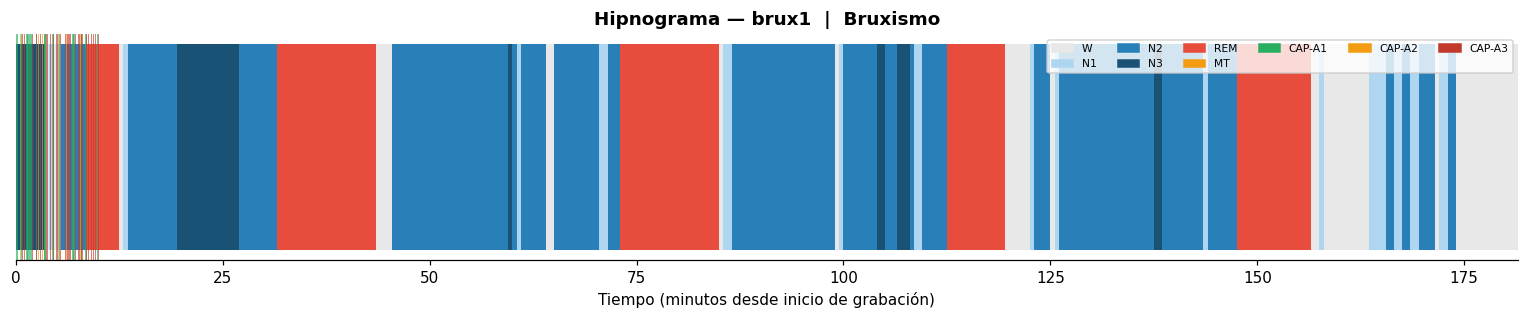

Eventos CAP-A en brux1: 60
subtype
CAP-A3    28
CAP-A1    26
CAP-A2     6


In [45]:
PACIENTE = stages_all['patient'].unique()[0]   # ← cambia aquí

df_p  = stages_all[stages_all['patient'] == PACIENTE].sort_values('onset_s')
cap_p = cap_all[cap_all['patient'] == PACIENTE].sort_values('onset_s')

fig, ax = plt.subplots(figsize=(14, 3))

for _, row in df_p.iterrows():
    ax.barh(
        y=0,
        width=row['duration_s'],
        left=row['onset_s'] / 60,
        color=STAGE_COLORS.get(row['stage_code'], '#CCCCCC'),
        height=0.8,
        align='center',
    )

for _, row in cap_p.iterrows():
    ax.axvline(
        row['onset_s'] / 60,
        color=CAP_COLORS.get(row['subtype'], '#888888'),
        lw=0.6,
        alpha=0.7,
    )

stage_patches = [
    mpatches.Patch(color=STAGE_COLORS[c], label=STAGE_CODE_TO_LABEL[c])
    for c in sorted(STAGE_COLORS)
]
cap_patches = [mpatches.Patch(color=v, label=k) for k, v in CAP_COLORS.items()]
ax.legend(handles=stage_patches + cap_patches, loc='upper right', fontsize=7, ncol=6)

ax.set_yticks([0])
ax.set_yticklabels([''])
ax.set_xlabel('Tiempo (minutos desde inicio de grabación)')
ax.set_title(f'Hipnograma — {PACIENTE}  |  {get_disorder(PACIENTE)}', fontweight='bold')
ax.set_xlim(0, df_p['onset_s'].max() / 60 + 5)
sns.despine(left=True)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

print(f'Eventos CAP-A en {PACIENTE}: {len(cap_p)}')
if not cap_p.empty:
    print(cap_p['subtype'].value_counts().to_string())

## 6 · Análisis de eventos CAP

In [46]:
# Resumen por paciente — subtypes comparados contra 'CAP-A1' etc. (formato correcto)
cap_summary = (
    cap_all
    .groupby('patient')
    .agg(
        disorder    = ('disorder', 'first'),
        total_cap   = ('subtype', 'count'),
        total_dur_s = ('duration_s', 'sum'),
        mean_dur_s  = ('duration_s', 'mean'),
        n_A1        = ('subtype', lambda x: (x == 'CAP-A1').sum()),
        n_A2        = ('subtype', lambda x: (x == 'CAP-A2').sum()),
        n_A3        = ('subtype', lambda x: (x == 'CAP-A3').sum()),
    )
    .round(2)
    .reset_index()
    .sort_values('total_cap', ascending=False)
)

patients_with_cap = cap_all['patient'].nunique()
total_patients    = stages_all['patient'].nunique()

print(f'Pacientes con eventos CAP : {patients_with_cap} / {total_patients}')
print(f'Total eventos CAP-A       : {len(cap_all):,}')
print(f'Duración media de CAP-A   : {cap_all["duration_s"].mean():.1f} s')
print()
display(cap_summary.head(15))

Pacientes con eventos CAP : 108 / 108
Total eventos CAP-A       : 49,956
Duración media de CAP-A   : 8.4 s



,patient,disorder,total_cap,total_dur_s,mean_dur_s,n_A1,n_A2,n_A3
45,nfle21,Epilepsia nocturna frontal,906,6463.0,7.13,483,258,165
69,nfle7,Epilepsia nocturna frontal,898,6814.0,7.59,670,111,117
36,nfle13,Epilepsia nocturna frontal,897,6087.0,6.79,448,201,248
107,sdb4,Trastorno respiratorio,830,10347.0,12.47,312,87,431
66,nfle40,Epilepsia nocturna frontal,784,7435.0,9.48,270,193,321
86,rbd13,Trastorno REM,743,7629.0,10.27,132,123,488
75,plm3,Movimientos periódicos,742,5661.0,7.63,330,165,247
93,rbd2,Trastorno REM,711,6163.0,8.67,375,202,134
95,rbd21,Trastorno REM,688,5503.0,8.00,321,152,215
63,nfle38,Epilepsia nocturna frontal,674,6265.0,9.30,396,112,166


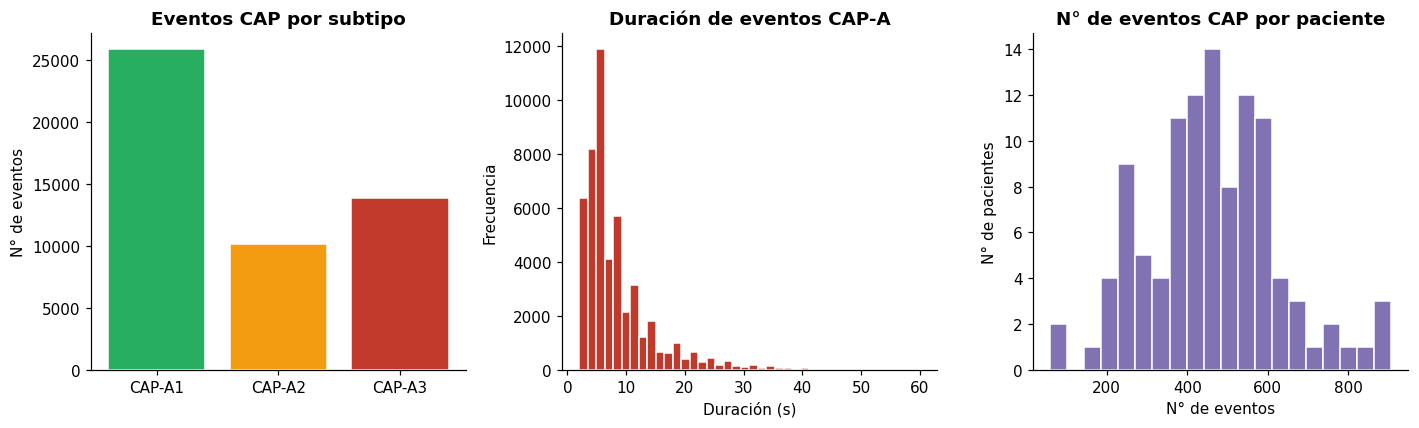

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

subtype_counts = cap_all['subtype'].value_counts().reindex(['CAP-A1', 'CAP-A2', 'CAP-A3'], fill_value=0)
axes[0].bar(
    subtype_counts.index,
    subtype_counts.values,
    color=[CAP_COLORS[k] for k in subtype_counts.index],
    edgecolor='white',
)
axes[0].set_title('Eventos CAP por subtipo', fontweight='bold')
axes[0].set_ylabel('N° de eventos')
sns.despine(ax=axes[0])

axes[1].hist(cap_all['duration_s'].clip(upper=60), bins=40, color='#C0392B', edgecolor='white')
axes[1].set_title('Duración de eventos CAP-A', fontweight='bold')
axes[1].set_xlabel('Duración (s)')
axes[1].set_ylabel('Frecuencia')
sns.despine(ax=axes[1])

axes[2].hist(cap_summary['total_cap'], bins=20, color='#8172B3', edgecolor='white')
axes[2].set_title('N° de eventos CAP por paciente', fontweight='bold')
axes[2].set_xlabel('N° de eventos')
axes[2].set_ylabel('N° de pacientes')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

## 7 · Balance de clases y distribución de etapas por trastorno

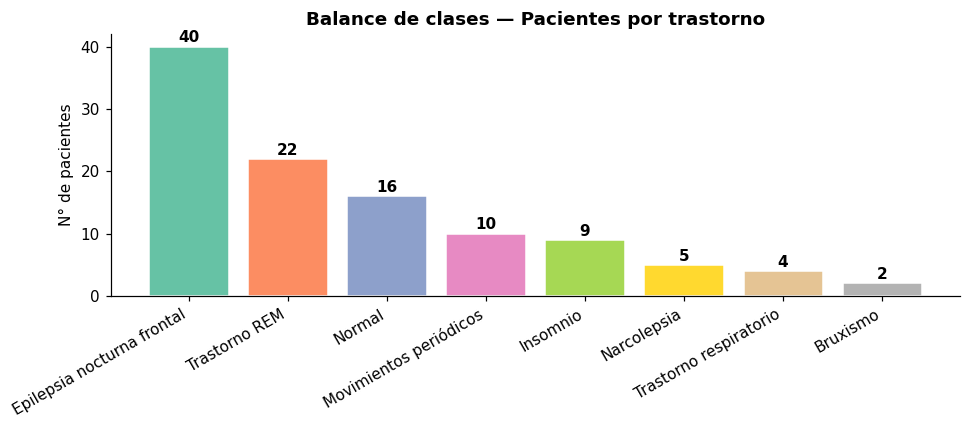

,disorder,n_pacientes
1,Epilepsia nocturna frontal,40
6,Trastorno REM,22
5,Normal,16
3,Movimientos periódicos,10
2,Insomnio,9
4,Narcolepsia,5
7,Trastorno respiratorio,4
0,Bruxismo,2


In [48]:
disorder_counts = (
    stages_all[['patient', 'disorder']]
    .drop_duplicates()
    .groupby('disorder')['patient']
    .count()
    .reset_index(name='n_pacientes')
    .sort_values('n_pacientes', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette('Set2', len(disorder_counts))
bars = ax.bar(disorder_counts['disorder'], disorder_counts['n_pacientes'],
              color=palette, edgecolor='white')
for bar, val in zip(bars, disorder_counts['n_pacientes']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_title('Balance de clases — Pacientes por trastorno', fontsize=12, fontweight='bold')
ax.set_ylabel('N° de pacientes')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

display(disorder_counts)

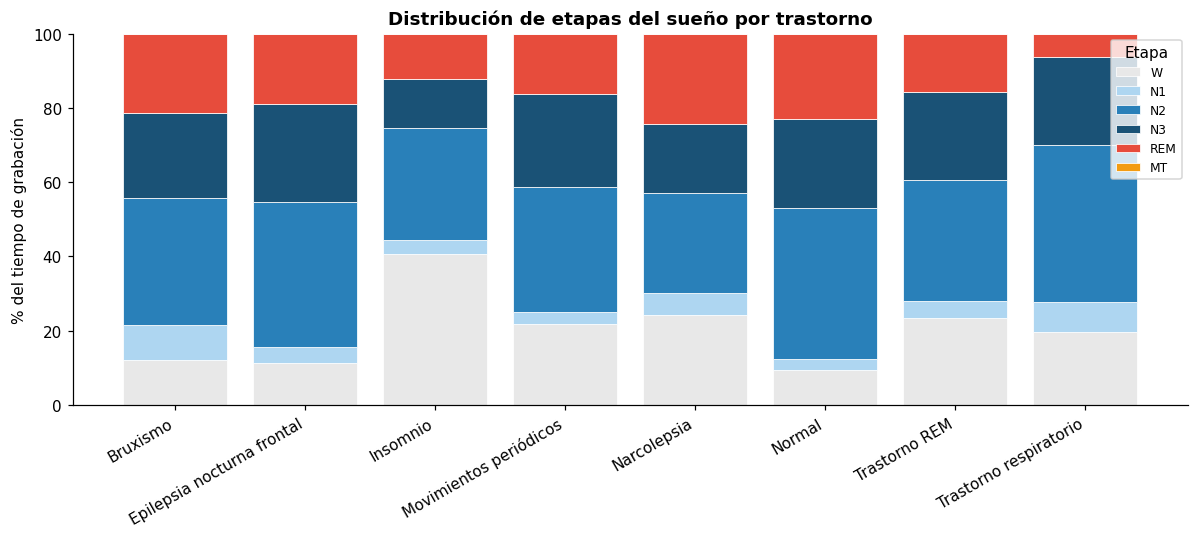

In [49]:
stage_by_disorder = (
    stages_all
    .groupby(['disorder', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
)
stage_by_disorder['pct'] = (
    stage_by_disorder
    .groupby('disorder')['duration_s']
    .transform(lambda x: x / x.sum() * 100)
)

pivot_stages = (
    stage_by_disorder
    .pivot(index='disorder', columns='stage_label', values='pct')
    .fillna(0)
)

stage_order = [STAGE_CODE_TO_LABEL[c] for c in sorted(STAGE_COLORS)
               if STAGE_CODE_TO_LABEL[c] in pivot_stages.columns]
bar_colors  = [STAGE_COLORS[STAGE_LABEL_TO_CODE[s]] for s in stage_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(pivot_stages))
for stage, color in zip(stage_order, bar_colors):
    vals = pivot_stages[stage].values
    ax.bar(pivot_stages.index, vals, bottom=bottom, label=stage,
           color=color, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_ylabel('% del tiempo de grabación')
ax.set_title('Distribución de etapas del sueño por trastorno', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, title='Etapa')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

## 8 · Exportar resultados

In [50]:
stages_all.to_csv(OUT_DIR / '07_hipnograma_completo.csv', index=False)
cap_all.to_csv(OUT_DIR / '08_eventos_cap.csv', index=False)
cap_summary.to_csv(OUT_DIR / '09_resumen_cap_por_paciente.csv', index=False)
disorder_counts.to_csv(OUT_DIR / '10_balance_clases.csv', index=False)

print(f'CSVs guardados en: {OUT_DIR.resolve()}')
print()
print('  07_hipnograma_completo.csv       — etapas con stage_code y stage_label')
print('  08_eventos_cap.csv               — eventos CAP-A con subtype correcto')
print('  09_resumen_cap_por_paciente.csv  — n_A1 / n_A2 / n_A3 corregidos')
print('  10_balance_clases.csv            — pacientes por trastorno')

CSVs guardados en: C:\Users\LilyG\Documents\Fusión de Datos\RAHBFDP-2026\data\diagnostico_outputs

  07_hipnograma_completo.csv       — etapas con stage_code y stage_label
  08_eventos_cap.csv               — eventos CAP-A con subtype correcto
  09_resumen_cap_por_paciente.csv  — n_A1 / n_A2 / n_A3 corregidos
  10_balance_clases.csv            — pacientes por trastorno
